# 1D Demo
This notebook shows the most important and usefull features of the Subwavelength 1D code


In [ ]:
# You need to run the code form the /subwavelength-physics directory
import os
os.chdir("..")


In [26]:
from Subwavelength1D.classic import ClassicFiniteSWP1D
from Subwavelength1D.simulation import ClassicFiniteSWP1DSolverFlux, plot_wave_solution_heatmap

import numpy as np

## Basic function

In [4]:
fwp = ClassicFiniteSWP1D(N=3, l=1,s=1)
fwp

One Dimensional Finite system with 3 resonators.
Geometry:     The first lengths are [1. 1. 1.] and the first spacings are [1. 1.]. 
Physics: Classic

In [ ]:
# One can then compute the capacitance matrix associated to the system
C = fwp.get_capacitance_matrix()
C

array([[ 1., -1.,  0.],
       [-1.,  2., -1.],
       [ 0., -1.,  1.]])

In [8]:
# If we set a frequency, we can also compute the propagation matrices
fwp = ClassicFiniteSWP1D(N=3, l=1,s=1, omega=1)
fwp.compute_propagation_matrix(space_from_end=2,subwavelength=True)

array([[-1., -1.],
       [ 0., -1.]])

## Time simulation

In [9]:
# We have a naive implementation of a time simulation for the systems

In [12]:
delta = 1e-2
fwp = ClassicFiniteSWP1D(
    N=2,
    l=1.0,
    s=1.0,
    v_in=1.0,
    v_out=1.0,
    delta=delta,
)

In [19]:
resonances = np.sqrt(delta*fwp.compute_sorted_eigs_capacitance_matrix()[0])
print(resonances)

[0.         0.14142136]


In [20]:
omega_in = resonances[-1]

# A simple function for the left boundary injection with frequency the first non-trivial resonance frequency of the system
def left_bc_sin(t, amplitude=1.0, omega_in=omega_in, end_time=None):
    return amplitude * np.cos(omega_in * t) if end_time is None or t < end_time else 0.0


In [23]:
solver = ClassicFiniteSWP1DSolverFlux(
    problem=fwp,
    Nx=500,
    T=1000.0,
    x_padding=(1, 1),
    bc_left="absorbing",
    bc_right="absorbing",
    point_source_loc=-0.5,
    point_source_func=left_bc_sin,
)

# The solver.x array gives the spatial mesh
x_grid = solver.xx
t_grid = solver.tt
time_step_count = solver.nt
dt = solver.dt

print(f"Computing solution with {time_step_count} time steps of size dt={dt:g}")

Computing solution with 110889 time steps of size dt=0.00901804


In [24]:
u_time_series = solver.solve()

100%|██████████| 110888/110888 [01:03<00:00, 1732.70it/s]


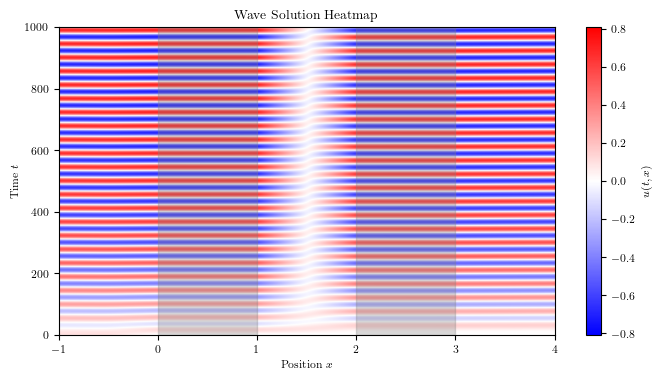

In [27]:
plot_wave_solution_heatmap(t_grid, x_grid, u_time_series, fwp)

### A more interesting simulation

In [30]:
delta = 1e-2
fwp = ClassicFiniteSWP1D.get_SSH(i=5,s1=1, s2=2,v_in=1.0,
    v_out=1.0,
    delta=delta,)

In [35]:
resonances = np.sqrt(delta*fwp.compute_sorted_eigs_capacitance_matrix()[0])
print(resonances)

[       nan 0.01200818 0.02431614 0.03564105 0.04793629 0.05805631
 0.07005017 0.07811239 0.08929193 0.09362234 0.11035245 0.14259477
 0.14305115 0.14996981 0.15173666 0.15909428 0.16086731 0.16668931
 0.16777066 0.17154523 0.17187254]


/tmp/ipykernel_31594/2702875554.py:1: RuntimeWarning: invalid value encountered in sqrt
  resonances = np.sqrt(delta*fwp.compute_sorted_eigs_capacitance_matrix()[0])


In [36]:
omega_in = resonances[10]

# A simple function for the left boundary injection with frequency the first non-trivial resonance frequency of the system
def left_bc_sin(t, amplitude=1.0, omega_in=omega_in, end_time=None):
    return amplitude * np.cos(omega_in * t) if end_time is None or t < end_time else 0.0


In [40]:
solver = ClassicFiniteSWP1DSolverFlux(
    problem=fwp,
    Nx=500,
    T=2000.0,
    x_padding=(1, 1),
    bc_left="absorbing",
    bc_right="absorbing",
    point_source_loc=-0.5,
    point_source_func=left_bc_sin,
)

# The solver.x array gives the spatial mesh
x_grid = solver.xx
t_grid = solver.tt
time_step_count = solver.nt
dt = solver.dt

print(f"Computing solution with {time_step_count} time steps of size dt={dt:g}")

Computing solution with 20923 time steps of size dt=0.0955912


In [41]:
u_time_series = solver.solve()

100%|██████████| 20922/20922 [00:11<00:00, 1787.87it/s]


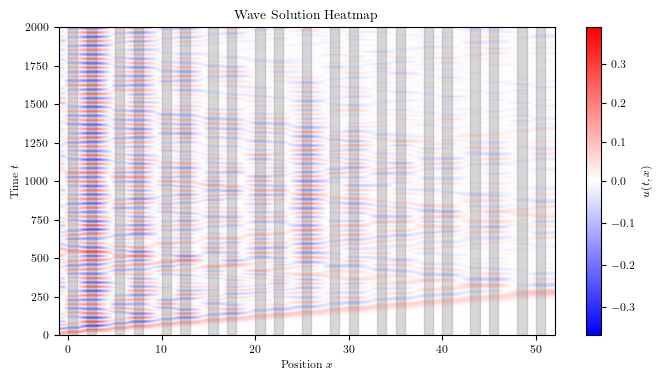

In [42]:
plot_wave_solution_heatmap(t_grid, x_grid, u_time_series, fwp)